# Section 2: API Setup and First AI Experience

> **Estimated time: 70–85 minutes**
> **Goal:** Configure an API Key, complete the first AI model call, and learn the basics of Prompt Engineering.
> **Done when:** Both `hello_llm.py` and `experiments/prompt_lab.py` run successfully and print an AI response.
> **Prerequisite:** Completed [Section 1](Section1_Environment_Git_GitHub.ipynb)

---

> **Note: Copy the commands below into a terminal and run them there. Do not run the code directly inside this Notebook.**

## 2.1 What Is an API?

### API Basics

An API (Application Programming Interface) is an agreed-upon way for two pieces of software to communicate with each other.

**An analogy:** Imagine eating at a restaurant. You (the program) want a dish, but you cannot walk into the kitchen (the AI model) and cook it yourself. You go through a waiter (the API) — you tell the waiter what you want, the waiter passes the order to the kitchen, and once the dish is ready the waiter brings it back to you.

```
You (code) → Waiter (API) → Kitchen (AI model)
                ↑                    |
                |                    |
                ←── result comes back ←───┘
```

In this workshop:
- **You (code):** the Python program you write
- **Waiter (API):** the interface provided by OpenRouter
- **Kitchen (AI model):** large language models such as ChatGPT, Claude, and Gemini

### Why It Matters

AI models run on remote servers and need massive computing resources. Through an API, code can send a request to a remote server, let the AI complete a task (answer questions, summarize text, analyze data), and receive the result back. The local computer does not need powerful hardware.

---

## 2.2 What Is OpenRouter?

### OpenRouter Basics

OpenRouter is an **AI model aggregation platform**. Think of it as a universal remote control — one remote (one API Key) can control many TVs (many AI models). Through a single interface you can call ChatGPT, Claude, Gemini, Llama, and many other models.

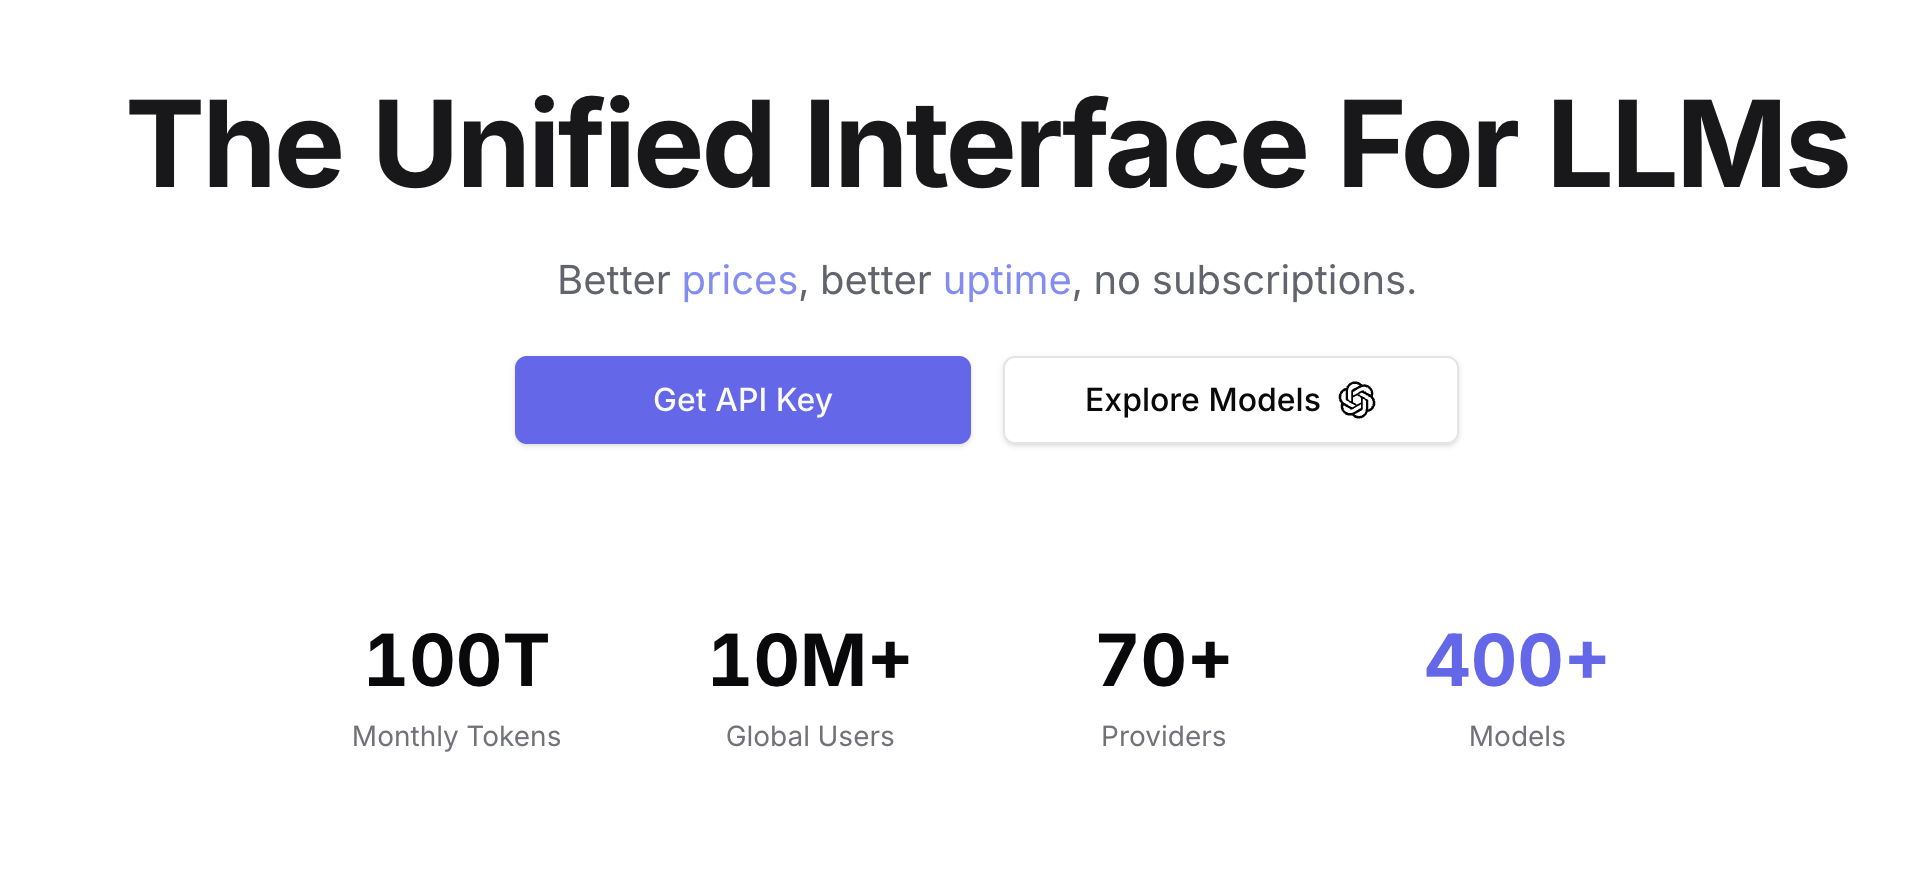

### Why It Matters

- **Model access:** one API can be used with different hosted models; availability and pricing can change
- **Unified interface:** one API Key gives access to dozens of models, with no need to register on each platform separately
- **OpenAI SDK compatible:** the code looks almost identical to calling ChatGPT directly, so the skills transfer seamlessly to other platforms

### What Is an API Key?

An API Key is an **identity credential**, similar to a bank card PIN. The platform uses it to identify who is calling and whether they have permission.

⚠️ **Important security note: an API Key is a password. Never share it with anyone, never upload it to GitHub, and never hard-code it in source code.** Later in this section we will learn how to store it safely.

---

## 2.3 Create a Python Virtual Environment

### Virtual Environment Basics

A virtual environment (`venv`) is an **isolated Python workspace**. Think of it as a separate box — packages installed inside the box belong only to the current project and never interfere with other projects.

**An analogy:** Suppose project A needs `openai` version 1.0 and project B needs `openai` version 2.0. Installing both into the global system environment creates a version conflict. A virtual environment gives each project its own independent space.

### Why It Matters

- Prevents dependency version conflicts between projects
- Keeps the system Python environment clean
- Makes it easy to manage each project's dependencies

### Steps

First, make sure you have run `cd` into the project folder (the one where you ran `git init` in Section 1).

#### Step 1: Create the virtual environment

In [ ]:
# Run in the terminal (not in the Python interactive shell)
# Mac / Linux:
# python3 -m venv venv
#
# Windows:
# python -m venv venv

What this command means:
- `python3 -m venv`: use Python's built-in `venv` module
- the final `venv`: the name of the virtual environment folder (`venv` is the conventional name)

> **Expected output:** The command produces no output (no error means success), and a new `venv/` folder appears in the project folder.

To verify:

In [ ]:
# Mac / Linux:
# ls venv/
#
# Windows:
# dir venv\

> **Expected output:** You will see subfolders such as `bin/` (Mac/Linux) or `Scripts/` (Windows), `lib/`, and `include/`.

#### Step 2: Activate the virtual environment

In [ ]:
# Mac / Linux:
# source venv/bin/activate
#
# Windows (PowerShell):
# .\venv\Scripts\Activate.ps1
#
# Windows (CMD):
# venv\Scripts\activate.bat

> **Expected output:** The terminal prompt gains a `(venv)` prefix, showing that the virtual environment is active:
>
> ```
> Before: username@computer project-folder %
> After:  (venv) username@computer project-folder %
> ```

![placeholder: terminal comparison before and after activating venv, note the added (venv) prefix]

⚠️ **Every new terminal window requires re-activating the virtual environment.** If packages installed with `pip install` seem to have disappeared, first check whether the prompt shows `(venv)`.

✅ **Checkpoint 1:** The terminal prompt shows `(venv)`, confirming the virtual environment is created and active.

> **Troubleshooting:**
> - `python3 -m venv venv` fails with `No module named venv` → the Python installation may be missing the `venv` module. On Ubuntu/Debian, run `sudo apt install python3-venv`
> - Windows PowerShell reports `cannot be loaded because running scripts is disabled` → run `Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope CurrentUser`, then activate again
> - Accidentally deleted the virtual environment folder → simply run `python3 -m venv venv` again to recreate it

---

## 2.4 Install Dependencies

### Basics

Dependencies are code libraries written by others that we can use directly. `pip` is Python's package manager, similar to an app store — tell it what to install, and it downloads and installs it.

### Dependency List

| Package | Purpose |
|------|------|
| `openai` | The official OpenAI SDK for calling AI model APIs. OpenRouter's interface is OpenAI-compatible, so this package works directly |
| `python-dotenv` | Reads configuration values (such as the API Key) from a `.env` file, keeping sensitive information out of source code |

### Steps

Make sure the virtual environment is active (the prompt shows `(venv)`), then run:

In [ ]:
# Run in the terminal (make sure (venv) is active):
# pip install openai python-dotenv

> **Expected output:** The installation prints download and setup messages, ending with:
>
> ```
> Successfully installed annotated-types-0.x.x anyio-4.x.x ... openai-1.x.x ... python-dotenv-1.x.x ...
> ```

(Exact version numbers may differ — seeing `Successfully installed` means success.)

**Verify the installation:**

In [ ]:
# Run in the terminal:
# pip list | grep -i -E "openai|dotenv"
#
# Windows users:
# pip list | findstr /i "openai dotenv"

> **Expected output:**
>
> ```
> openai              1.x.x
> python-dotenv       1.x.x
> ```

Both packages appear in the list, confirming the installation succeeded.

✅ **Checkpoint 2:** The `pip list` output includes `openai` and `python-dotenv`.

> **Troubleshooting:**
> - `pip: command not found` → try `pip3 install openai python-dotenv`, or `python3 -m pip install openai python-dotenv`
> - Installation is very slow → use a mirror to speed it up: `pip install openai python-dotenv -i https://pypi.tuna.tsinghua.edu.cn/simple`
> - `Permission denied` → the virtual environment is probably inactive; confirm the prompt shows `(venv)`

---

## 2.5 Register on OpenRouter and Get an API Key

### Steps

#### Step 1: Open the OpenRouter website

Visit [openrouter.ai](https://openrouter.ai) in a browser.

![placeholder: OpenRouter homepage screenshot]

#### Step 2: Sign up

1. Click **Sign In** at the top right of the page
2. Signing in with a **Google** or **GitHub** account is recommended (fastest, no registration form to fill out)
3. Without a Google/GitHub account, email registration also works

![placeholder: OpenRouter sign-in page with the Google and GitHub buttons highlighted]

#### Step 3: Open the API Keys page

After signing in:
1. Click the avatar or username at the top right
2. Select **Keys** from the dropdown menu
3. Or go directly to [openrouter.ai/keys](https://openrouter.ai/keys)

![placeholder: navigation path to the Keys page on OpenRouter]

#### Step 4: Create a new API Key

1. Click the **Create Key** button
2. Enter `workshop` in the Name field (a name makes the Key easy to recognize later)
3. Leave Credit limit at its default (no need to fill it in)
4. Click **Create**

![placeholder: Create Key dialog with workshop entered in the Name field]

#### Step 5: Copy the API Key

After creation, the page displays the new API Key. Its format looks like:

```
YOUR_OPENROUTER_API_KEY
```

⚠️ **The full Key is shown only once!** Copy it immediately and store it somewhere safe (for example, paste it into a temporary text file first). If the page is closed before copying, delete the Key and create a new one.

✅ **Checkpoint 3:** An API Key starting with `sk-or-v1-` has been copied.

> **Troubleshooting:**
> - Verification email never arrives → check the spam folder, or sign in with Google/GitHub instead
> - Forgot to copy the Key → delete the old Key on the Keys page and Create a new one

---

## 2.6 Store the API Key Safely (Using a `.env` File)

### `.env` File Basics

A `.env` file is a configuration file dedicated to storing **environment variables** — the configuration values a program needs at runtime, such as API Keys and database addresses.

### Why It Matters

- Hard-coding an API Key in source code is very dangerous — once the code lands on GitHub, everyone can see the Key
- A `.env` file separates secrets from code: the code only references a variable name, while the actual value lives in `.env`
- Combined with `.gitignore` (covered in the next step), Git will ignore the `.env` file so it is never uploaded

### Steps

Make sure you are in the root of the project folder.

**Option 1: Create it from the terminal**

In [ ]:
# Run in the terminal (replace YOUR_OPENROUTER_API_KEY with the real Key):
# echo "OPENROUTER_API_KEY=YOUR_OPENROUTER_API_KEY" > .env

What this command means:
- `echo "..."`: prints the text inside the quotes
- `>`: writes the output into a file (creating it if it does not exist)
- `.env`: the target file name

**Option 2: Create it manually in the editor (if the terminal command feels less intuitive)**

1. In your editor, create a new file in the project folder
2. Name the file `.env` (note the leading dot)
3. Put the following content in the file (replace with the real Key):

```
OPENROUTER_API_KEY=YOUR_OPENROUTER_API_KEY
```

4. Save the file (`Cmd + S` or `Ctrl + S`)

**Verify the `.env` file contents:**

In [ ]:
# Mac / Linux:
# cat .env
#
# Windows:
# type .env

> **Expected output:**
>
> ```
> OPENROUTER_API_KEY=YOUR_OPENROUTER_API_KEY...
> ```

⚠️ **Watch out for:**
- **No spaces** around the equals sign `=`
- **No quotes** around the Key value
- The file needs **only this one line** for now (more settings can be added later)

✅ **Checkpoint 4:** The project folder contains a `.env` file with the line `OPENROUTER_API_KEY=sk-or-v1-...`.

---

## 2.7 Protect Sensitive Files with `.gitignore`

### `.gitignore` Basics

`.gitignore` is a special configuration file that tells Git: "Ignore these files — do not track their changes and do not commit them to the repository."

### Why It Matters

- Prevents the `.env` file (which contains the API Key) from being uploaded to GitHub
- Excludes the `venv/` folder (virtual environments can be hundreds of MB and never belong in the repo)
- Excludes auto-generated Python cache files such as `__pycache__/`

### Steps

**Option 1: Create it from the terminal**

In [ ]:
# Run in the terminal (works on Mac / Linux / Windows):
#
# echo "venv/" > .gitignore
# echo ".env" >> .gitignore
# echo "__pycache__/" >> .gitignore
# echo "*.pyc" >> .gitignore

Note the difference:
- the first line uses `>` (overwrite — creates a new file)
- the following lines use `>>` (append — keeps the existing content)

**Option 2: Create it manually in the editor**

In your editor, create a new file named `.gitignore` with these four lines:

```
venv/
.env
__pycache__/
*.pyc
```

Save the file.

**What each line means:**

| Rule | Meaning |
|------|------|
| `venv/` | Ignore the virtual environment folder (it is large, and each person should create their own) |
| `.env` | Ignore the environment variable file (it contains the API Key and must never be uploaded) |
| `__pycache__/` | Ignore the Python cache folder (auto-generated, no need for version control) |
| `*.pyc` | Ignore all `.pyc` compiled cache files |

**Verify the `.gitignore` file contents:**

In [ ]:
# Mac / Linux:
# cat .gitignore
#
# Windows:
# type .gitignore

> **Expected output:**
>
> ```
> venv/
> .env
> __pycache__/
> *.pyc
> ```

**Commit `.gitignore` to the Git repository:**

`.gitignore` itself should be tracked by Git (it is part of the project configuration), so commit it:

In [ ]:
# Run in the terminal:
# git add .gitignore
# git commit -m "Add .gitignore to protect sensitive files"

> **Expected output:**
>
> ```
> [main xxxxxxx] Add .gitignore to protect sensitive files
>  1 file changed, 4 insertions(+)
>  create mode 100644 .gitignore
> ```

✅ **Checkpoint 5:** `.gitignore` has been created and committed to Git.

---

## 2.8 Verify the API Key Loads Correctly

Time for the final test: confirm the code can read the API Key from the `.env` file.

#### Step 1: Run the test command

In [ ]:
# Run in the terminal (make sure venv is active):
#
# python3 -c "
# import os
# from dotenv import load_dotenv
# load_dotenv()
# key = os.getenv('OPENROUTER_API_KEY')
# print('Key loaded:', key[:15] + '...' if key else 'NOT FOUND')
# "

What this code does:
1. `from dotenv import load_dotenv` — imports the `load_dotenv` function provided by `python-dotenv`
2. `load_dotenv()` — reads the `.env` file in the current directory and loads its variables into the environment
3. `os.getenv('OPENROUTER_API_KEY')` — retrieves the value of `OPENROUTER_API_KEY` from the environment
4. Prints the first 15 characters of the Key (only a portion, for safety)

> **Expected output (success):**
>
> ```
> Key loaded: YOUR_OPENROUTER_API_KEY...
> ```

The first few characters of the Key should appear.

> **Expected output (failure):**
>
> ```
> Key loaded: NOT FOUND
> ```

If `NOT FOUND` appears, check:
- Is the `.env` file in the current directory? (run `ls -a` to check)
- Is the variable name in `.env` spelled correctly? (`OPENROUTER_API_KEY`, all uppercase, separated by underscores)
- Are there stray spaces around the equals sign?

#### Step 2: Confirm `.env` is not tracked by Git

In [ ]:
# Run in the terminal:
# git status

> **Expected output:**
>
> The `git status` output should **not** mention the `.env` file. It may show `nothing to commit, working tree clean` or list other untracked files, but `.env` will be absent from the list — `.gitignore` has already told Git to ignore it.

If `.env` appears under `Untracked files` in `git status`, `.gitignore` is not working. Check that the `.gitignore` file correctly contains the `.env` line.

✅ **Checkpoint 6:** The `python3 -c "..."` command prints the Key prefix (`sk-or-v1-...`), and `.env` is absent from `git status`.

> **Troubleshooting:**
> - `ModuleNotFoundError: No module named 'dotenv'` → the virtual environment may be inactive, or `python-dotenv` is missing from the current venv. Run `pip install python-dotenv` and try again
> - `.env` shows up in `git status` → check that `.gitignore` was saved. If `.env` was already staged with `git add`, run `git rm --cached .env` to untrack it
> - Key shows `NOT FOUND` even though `.env` exists → confirm the command is being run in the same directory as the `.env` file

---

---

# Part 2: First AI Model Call

> The API Key is configured! Now it is time to talk to an AI using Python code.

## 2.9 What Is an LLM (Large Language Model)?

### LLM Basics

LLM stands for Large Language Model. It is an AI program trained by reading enormous amounts of text (books, web pages, code, and more), through which it has learned to "understand" and generate human language.

**Analogy:** Imagine a person who has read every book in the world — ask them any question, and they can give a pretty good answer. An LLM works in a similar way.

**Common LLMs:**

| Model | Company | Product you may have used |
|------|------|-------------------|
| GPT-4o | OpenAI | ChatGPT |
| Claude | Anthropic | claude.ai |
| Gemini | Google | Gemini App |
| Step | StepFun | Yuewen |

### Why It Matters

The core goal of this workshop is to call LLMs from code and let AI complete tasks for us (such as summarizing documents and answering questions). Understanding what an LLM is makes the upcoming code much easier to follow.

---

## 2.10 What Is an API Call?

### API Call Basics

API stands for Application Programming Interface. An analogy makes it concrete:

- **Using ChatGPT in the browser:** like dining at a restaurant — sit down, look at the menu, order, and the waiter brings the food. Communication with the AI happens through a web interface.
- **Calling the API from code:** like ordering delivery — place an order through an app (send a request), and the restaurant cooks the food and delivers it (returns the result). Communication with the AI happens through code.

**The same AI model sits behind both approaches** — only the way of communicating differs.

### API vs. Web Interface

| | Web interface | API call |
|---|---|---|
| How it works | Type and chat | Write code that sends requests |
| Best for | Everyday Q&A | Building AI applications |
| Automation | No — everything is manual | Yes — code runs automatically |
| Example | Manually paste in one article and ask "summarize this" | Code reads 100 articles and summarizes each one automatically |

**Key point:** This workshop teaches the API approach, which is what makes it possible to build real AI applications.

![placeholder: comparison diagram — web chat interface on the left, code terminal on the right, arrows pointing to the same AI model in the middle]

---

## 2.11 The AI Model and Platform We Use

### Model: `google/gemma-4-31b-it:free`

The workshop uses gemma-4-31b through OpenRouter. This exact model ID has been checked against the live OpenRouter endpoint for this delivery package.

### Platform: OpenRouter

OpenRouter provides an OpenAI-compatible API for hosted models. The Python exercises use it to teach API requests, responses, prompts, and token usage.

### Why This Choice

- The model is available through the workshop's tested endpoint
- It responds quickly enough for short classroom exercises
- The OpenAI-compatible request format transfers to other providers

---


## 2.12 Create `hello_llm.py` — First AI Program

Next we will write a Python file that sends a question to the AI model and prints the AI's answer.

#### Step 1: Create the file

Create a new file named `hello_llm.py` in the project folder. Use your editor, or run this command in the terminal:

In [ ]:
touch hello_llm.py

#### Step 2: Understand the code structure

Below is the complete code for `hello_llm.py`. Before copying it, let's walk through what each line does:

In [ ]:
# hello_llm.py
import os                          # Built-in Python module for reading environment variables
from dotenv import load_dotenv     # Loads environment variables from the .env file
import openai                      # Official OpenAI SDK for calling AI models

load_dotenv()
api_key = os.getenv("OPENROUTER_API_KEY")
if not api_key:
    raise SystemExit("OPENROUTER_API_KEY is missing. Add it to .env and try again.")                      # Read the API Key from the .env file

client = openai.OpenAI(            # Create a "client" object
    base_url="https://openrouter.ai/api/v1",   # Point it at OpenRouter
    api_key=api_key,    # Read the Key from .env
)

response = client.chat.completions.create(      # Send the request to the AI
    model="google/gemma-4-31b-it:free",        # Which model to use
    messages=[                                   # The conversation content
        {"role": "user", "content": "What is Python in 2 sentences?"}
    ],
)

print(response.choices[0].message.content)      # Extract and print the AI's answer

### Line-by-Line Walkthrough

| Lines | Code | What it does |
|------|------|----------|
| 1–3 | `import os` / `from dotenv ...` / `import openai` | **Import the libraries.** Like laying out the knife, cutting board, and seasonings before cooking. `os` reads environment variables, `dotenv` loads the `.env` file, and `openai` is the SDK for calling AI models. |
| 5 | `load_dotenv()` | **Load the `.env` file.** After this runs, the `OPENROUTER_API_KEY=YOUR_OPENROUTER_API_KEY` line from `.env` is in memory, ready to be fetched with `os.getenv()`. |
| 7–10 | `client = openai.OpenAI(...)` | **Create the client.** Think of it as dialing a phone — `base_url` is the phone number (pointing to OpenRouter) and `api_key` is proof of identity. |
| 12–16 | `client.chat.completions.create(...)` | **Send the message.** `model` picks which AI to use, and `messages` holds the question. Like sending the AI a text message. |
| 18 | `print(response.choices[0].message.content)` | **Read the answer.** The AI's reply is nested inside the `response` object; this line extracts it. |

![placeholder: code flow diagram — load Key from .env, create client, send messages, receive response, extract content]

---

### Understanding the `messages` Conversation Format

Conversations with an AI model are organized as a `messages` array. Every message has two fields:

- `role`: who is speaking
- `content`: what was said

**The three roles:**

| Role | Who is speaking | Purpose | Analogy |
|------|----------|------|------|
| `system` | The developer (you) | Sets the AI's behavior and persona | A job description for a new employee |
| `user` | The user | The user's question or request | A customer placing an order |
| `assistant` | The AI | The AI's reply | The waiter's response |

**Example:**
```python
messages = [
    {"role": "system", "content": "You are a helpful teacher."},     # Sets the AI's persona
    {"role": "user", "content": "What is an API?"},                  # The student asks
    {"role": "assistant", "content": "An API is like a waiter..."},   # The AI's earlier answer
    {"role": "user", "content": "Can you give me an example?"},      # The student follows up
]
```

On every API call, the AI sees the entire `messages` array as context and then generates the next reply. This is how it "remembers" earlier parts of the conversation.

---

## 2.13 Hands-On Exercise: Fill In the TODO

Open `hello_llm.py` in your editor and type in the code below.

**Note:** There is a `# TODO` inside `messages` that you need to complete.

In [ ]:
# hello_llm.py
import os
from dotenv import load_dotenv
import openai

load_dotenv()
api_key = os.getenv("OPENROUTER_API_KEY")
if not api_key:
    raise SystemExit("OPENROUTER_API_KEY is missing. Add it to .env and try again.")

client = openai.OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=api_key,
)

response = client.chat.completions.create(
    model="google/gemma-4-31b-it:free",
    messages=[
        # TODO: add a message with role "user" and content "What is Python in 2 sentences?"
    ],
)

print(response.choices[0].message.content)

### Hint

Each message is a Python dictionary:
```python
{"role": "the_role", "content": "the_content"}
```

Add one message of this form to the `messages` array.

---

### Reference Answer

After filling it in, `messages` should look like this:

In [ ]:
    messages=[
        {"role": "user", "content": "What is Python in 2 sentences?"}
    ],

The complete `hello_llm.py` should look like this:

In [ ]:
# hello_llm.py — complete version
import os
from dotenv import load_dotenv
import openai

load_dotenv()
api_key = os.getenv("OPENROUTER_API_KEY")
if not api_key:
    raise SystemExit("OPENROUTER_API_KEY is missing. Add it to .env and try again.")

client = openai.OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=api_key,
)

response = client.chat.completions.create(
    model="google/gemma-4-31b-it:free",
    messages=[
        {"role": "user", "content": "What is Python in 2 sentences?"}
    ],
)

print(response.choices[0].message.content)

---

## 2.14 Run the First AI Program

Make sure you are in the project folder (with the virtual environment activated), then run:

In [ ]:
python3 hello_llm.py

> **Expected output:**
>
> The terminal prints an AI-generated introduction to Python, roughly 2–3 sentences. For example:
>
> ```
> Python is a high-level, interpreted programming language known for its clear
> and readable syntax, making it an excellent choice for beginners and experienced
> developers alike. It supports multiple programming paradigms and has a vast
> ecosystem of libraries for web development, data science, AI, and more.
> ```

> **Important:** The answer will differ from the example above. AI is non-deterministic — the same question can produce a different answer on every run. This is normal!

![placeholder: terminal screenshot of hello_llm.py running successfully and printing the AI's answer]

✅ **Checkpoint 1:** `python3 hello_llm.py` runs successfully and the terminal prints the AI's answer about Python.

---

### Troubleshooting

| Error message | Cause | Fix |
|----------|------|----------|
| `ModuleNotFoundError: No module named 'dotenv'` | The `python-dotenv` library is not installed | Run `pip3 install python-dotenv` |
| `ModuleNotFoundError: No module named 'openai'` | The `openai` library is not installed | Run `pip3 install openai` |
| `AuthenticationError` or `401 Unauthorized` | API Key is invalid or failed to load | Check that `.env` exists, the variable is named `OPENROUTER_API_KEY`, and the Key starts with `sk-or-v1-` |
| `429 Too Many Requests` | Requests too frequent — the free model's rate limit was reached | Wait 30 seconds and retry |
| `ConnectionError` or `timeout` | Network problem | Check the network connection and make sure `openrouter.ai` is reachable |
| Terminal exits with no output at all | The virtual environment may be inactive | Run `source venv/bin/activate` (Mac) or `venv\\Scripts\\activate` (Windows) |

---
> - `ImportError: Using SOCKS proxy, but the 'socksio' package is not installed` → run `pip install "httpx[socks]"`, then retry


## 2.15 Experiment 1: Exploring Temperature

### Temperature Basics

`temperature` is a parameter that controls how random the AI's answers are, with values from 0.0 to 2.0.

| Temperature | AI behavior | Analogy |
|-------------|----------|------|
| `0.0` | Most stable and predictable — answers are nearly identical every time | A standard exam answer |
| `0.7` | A good balance (the default) | Everyday conversation |
| `1.0–2.0` | More creative, but also less controllable | Writing poetry or stories |

### Why It Matters

Choosing the right temperature for the task makes the AI perform better. For example, use a low temperature when summarizing documents (to stay accurate) and a high temperature for creative copywriting (to add variety).

### Experiment Steps

#### Step 1: Run twice with `temperature=0.0`

Edit `hello_llm.py` and add a `temperature` parameter to `client.chat.completions.create()`:

In [ ]:
response = client.chat.completions.create(
    model="google/gemma-4-31b-it:free",
    messages=[
        {"role": "user", "content": "What is Python in 2 sentences?"}
    ],
    temperature=0.0,    # <-- the new parameter
)

Save the file, then run it twice:

In [ ]:
python3 hello_llm.py
python3 hello_llm.py

> **Expected output:** The two runs should produce nearly identical (or very similar) output.

---

#### Step 2: Change to `temperature=1.0` and run twice more

Change `temperature=0.0` to `temperature=1.0` in the code, save, and run twice:

In [ ]:
python3 hello_llm.py
python3 hello_llm.py

> **Expected output:** The two runs should differ noticeably — wording, sentence structure, and emphasis will all vary.

✅ **Checkpoint 2:** You observed firsthand that `temperature=0.0` produces stable output and `temperature=1.0` produces varied output.

> **Tip:** After the experiment, feel free to remove the `temperature` parameter (or keep a preferred value) — it does not affect the rest of the workshop.

---

## 2.16 Experiment 2: Exploring the System Message

### System Message Basics

The system message is the message in the `messages` array whose `role` is `"system"`. It gives the AI a persona or a set of behavior rules — like handing a new employee a job description that says who they are and how they should act.

### Why It Matters

The system message is one of the most important tools for controlling AI behavior. Later, when building the SmartLearn Agent, a system message will make the AI play the role of an intelligent teaching assistant.

### Experiment Steps

Edit `hello_llm.py` and add a system message to the `messages` array, placed **before** the user message:

In [ ]:
response = client.chat.completions.create(
    model="google/gemma-4-31b-it:free",
    messages=[
        {"role": "system", "content": "You are a pirate. Answer everything in pirate speak."},
        {"role": "user", "content": "What is Python in 2 sentences?"}
    ],
)

Save and run:

In [ ]:
python3 hello_llm.py

> **Expected output:** The AI answers the Python question in pirate speak. For example:
>
> ```
> Arrr, Python be a mighty fine programmin' language, easy to learn and
> read like a treasure map, matey! It be used fer all sorts o' adventures
> from web development to data science and even artificial intelligence, yarr!
> ```

✅ **Checkpoint 3:** The AI answered in pirate speak, proving that the system message really does control the AI's behavior.

---

### Extension Exercise (optional)

Try swapping in the following system messages and watch how the answers change:

- `"You are a kindergarten teacher. Explain things simply for 5 year olds."`
- `"You are a strict professor. Be very technical and precise."`
- `"You are a classical poet. Answer everything in rhyming verse."`

**Key takeaway:** The system message is the switch that controls the AI's behavior and persona. The same model with a different system message feels like a completely different AI assistant.

---

## 2.17 Understanding the API Request and Response Format

Running `hello_llm.py` actually performs an HTTP request under the hood, with data transferred in JSON format. Understanding this format helps with debugging and with handling more complex scenarios.

### What Gets Sent (Request)

In [ ]:
# The JSON data the code actually sends (simplified):
{
    "model": "google/gemma-4-31b-it:free",
    "messages": [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "What is Python?"}
    ],
    "temperature": 0.7
}

### What the AI Returns (Response)

In [ ]:
# The JSON data the AI returns (simplified):
{
    "choices": [
        {
            "message": {
                "role": "assistant",
                "content": "Python is a high-level programming language..."
            }
        }
    ],
    "usage": {
        "prompt_tokens": 25,
        "completion_tokens": 50,
        "total_tokens": 75
    }
}

### Inspecting the Actual Response in Code

We can modify `hello_llm.py` to print details from the response object and see the real structure. Add these lines at the end of the file:

In [ ]:
# Add these lines at the end of hello_llm.py to see response details and token usage:
print("\n--- Details ---")
print(f"Model: {response.model}")
print(f"Prompt tokens:     {response.usage.prompt_tokens}")
print(f"Completion tokens: {response.usage.completion_tokens}")
print(f"Total tokens:      {response.usage.total_tokens}")

After running, the output looks something like this:

```
Python is a high-level, interpreted programming language...

--- Details ---
Model: google/gemma-4-31b-it:free
Prompt tokens:     25
Completion tokens: 48
Total tokens:      73
```

### Understanding Tokens

#### Token Basics

A token is a unit of text processed by the model. Token counts vary by language and tokenizer, so word-to-token estimates are only rough guides.

#### Why It Matters

- **Billing:** OpenRouter charges according to the selected model and token usage
- **Length limits:** the prompt and generated answer must fit within the model's context and output limits
- **Performance:** longer prompts and answers usually take more time and cost more

The response object's `usage` fields show the token counts for the completed request.


---

# Part 3: Prompt Engineering Lab

> Calling the API is only the starting point. Now you will treat prompts as testable inputs: predict, run, compare, measure, and revise.

You must complete four practical comparisons before moving to Claude Code:

1. Vague request vs role/constraint/format
2. Confident hallucination vs evidence-grounded refusal
3. `It does not work` vs a complete traceback prompt
4. One-line feature request vs a Mini PRD with acceptance tests

## 2.18 Prompt Engineering Is Experimental Design

A useful prompt is not simply 'more detailed'. It defines enough information for the result to be **useful, bounded, and testable**.

### The six-part practical prompt

| Part | Question it answers | Example |
|---|---|---|
| Context | Who is using this and why? | `A first-year student is preparing for a quiz.` |
| Task | What exact job should the model do? | `Turn the notes into a revision card.` |
| Input | What material may it use? | `Use only the numbered paragraphs below.` |
| Constraints | What must it avoid or limit? | `Under 120 words; no outside facts.` |
| Output | What shape should the answer have? | `Definition / example / common mistake.` |
| Done when | How will we decide pass/fail? | `All three headings exist and every fact has a citation.` |

### The classroom loop

For every experiment: **change one variable only**. Keep the model and temperature fixed, predict the outcome before running, then compare the actual result against explicit checks. This is why an API script is more useful than three unrelated chat screenshots.

> Later, the same six parts become a Claude Code instruction. The difference is risk: a coding agent can change files and run commands, so `plan first`, `show diff`, and `run tests` become mandatory.

---

## 2.19 Create the Experiment Directory and File

First, create an `experiments/` folder to hold the prompt engineering experiment code.

### Basics

`mkdir -p` is the command for creating a folder. The `-p` flag means "skip if the folder already exists, create it if not" — so the command never errors no matter how many times it runs.

### Steps

#### Step 1: Make sure you are in the project root

Run in the terminal:

In [ ]:
# Confirm the current directory (it should be the project root)
!pwd

> **Expected output:**
> ```
> /Users/your_username/your_project_name
> ```

If not in the project root, use `cd` to move there.

#### Step 2: Create the `experiments/` directory

In [ ]:
!mkdir -p experiments

> **Expected output:**
>
> No output means success. Confirm the folder exists with `ls`:

In [ ]:
!ls experiments/

> **Expected output:**
> ```
> (blank — the folder has no files yet)
> ```

✅ **Checkpoint 1:** The `experiments/` folder has been created.

---

## 2.20 Understanding the Three Prompt Levels

Before writing code, let's understand the three quality levels of a prompt. The same question — **"explain Python lists"** — asked in three different ways gets completely different answers from the AI.

### Level A: Vague Prompt

```
Explain Python lists
```

**What's wrong with it?** The AI has no idea:
- Is the asker a beginner or an experienced programmer?
- How long should the explanation be?
- What format is wanted? A paragraph of text? Code examples?

Result: a long, generic, textbook-style answer — possibly too long, too shallow, or full of unfamiliar jargon.

---

### Level B: Structured Prompt

```
You are a Python tutor for beginners. Explain Python lists in under 100 words.
```

**What improved?** Two key pieces of information were added:
- **Role:** `You are a Python tutor for beginners` — the AI knows to use simple language
- **Constraint:** `in under 100 words` — the AI knows to be concise

Result: the answer is more targeted, the language friendlier, and the length appropriate.

---

### Level C: Precise Prompt

```
You are a Python tutor for beginners. Explain Python lists.
Format:
1) One-sentence definition
2) Three common operations with code examples
3) One common mistake to avoid
```

**What improved?** On top of Level B, this also specifies the **output format**:
- The AI knows exactly how the answer should be structured
- The answer becomes predictable and structured
- Information density is highest — ideal for learning

---

### The Three Levels at a Glance

| Level | Elements included | Result quality |
|------|----------|----------|
| Level A | Just the question | Generic, unpredictable quality |
| Level B | Question + role + constraint | Targeted and concise |
| Level C | Question + role + constraint + output format | Structured, information-dense, most practical |

For this warm-up we add three pieces: **Role + Constraint + Output Format**. In real tasks, also add context, allowed evidence/input, and a pass/fail definition.

![placeholder: side-by-side comparison of the three prompt levels and the AI answers each one produces]

---

## 2.21 Create the Experiment Script

Now let's write a Python script that automatically sends the three levels of prompts to the AI and compares the answers.

### Basics

The `prompt_lab.py` script will:
1. Define an `ask()` function that calls the AI API
2. Send three prompts of different quality
3. Print all three answers so they are easy to compare

### Why It Matters

Trying prompts one by one in ChatGPT works too, but a script has two advantages:
- **Repeatable:** re-run it any time with different prompts
- **Comparable:** all three answers print together, making the differences obvious at a glance

### Steps

Using your editor, create `prompt_lab.py` inside the `experiments/` folder with the following code:

```python
import os
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()
api_key = os.getenv("OPENROUTER_API_KEY")
if not api_key:
    raise SystemExit("OPENROUTER_API_KEY is missing. Add it to .env and try again.")

# Initialize the OpenAI-compatible client for OpenRouter
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=api_key,
)


def ask(prompt: str) -> str:
    """Send one prompt to the AI and return the answer text."""
    response = client.chat.completions.create(
        model="google/gemma-4-31b-it:free",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=300,
    )
    return response.choices[0].message.content


# ============================================================
#  Three levels of prompts — topic: Python Lists
# ============================================================

# Level A: Vague Prompt
# TODO: write a vague question about Python lists
prompt_a = ""  # <-- fill in the prompt here

# Level B: Structured Prompt (add a role + constraint)
# TODO: write a prompt with a role and a constraint
prompt_b = ""  # <-- fill in the prompt here

# Level C: Precise Prompt (role + constraint + output format)
# TODO: write a prompt with a role, a constraint, and an output format
prompt_c = ""  # <-- fill in the prompt here


# ============================================================
#  Run the experiment and print the results
# ============================================================
if __name__ == "__main__":
    prompts = {
        "Level A (Vague)": prompt_a,
        "Level B (Structured)": prompt_b,
        "Level C (Precise)": prompt_c,
    }

    for level, prompt in prompts.items():
        if not prompt:
            print(f"\n{'='*60}")
            print(f"  {level}: (empty -- fill in the TODO above!)")
            print(f"{'='*60}")
            continue

        print(f"\n{'='*60}")
        print(f"  {level}")
        print(f"  Prompt: {prompt[:80]}{'...' if len(prompt) > 80 else ''}")
        print(f"{'='*60}")
        answer = ask(prompt)
        print(answer)
```

> **Important boundary:** this script calls OpenRouter so you can learn API structure and compare prompts. Claude Code uses DeepSeek directly through `ANTHROPIC_BASE_URL`; it does not call DeepSeek through OpenRouter.

**Confirm the file was created:**

In [ ]:
!ls experiments/prompt_lab.py

> **Expected output:**
> ```
> experiments/prompt_lab.py
> ```

If it prints `No such file or directory`, the file has not been saved yet — go back to the editor and check.

✅ **Checkpoint 2:** `experiments/prompt_lab.py` exists and contains the `ask()` function and the three TODO prompts.

> **Troubleshooting:**
> - Not sure where the API key comes from → revisit Section 2.6 and confirm `OPENROUTER_API_KEY` is present in `.env`
> - Authentication fails → confirm the key starts with `sk-or-v1-` and the client uses `https://openrouter.ai/api/v1`

---

## 2.22 Fill In the Prompts (Hands-On Exercise)

Open `experiments/prompt_lab.py`, find the three `TODO` markers, and fill in self-written prompts.

All three prompts cover the same topic — **Python lists** — but asked in three different ways.

### The Task

1. **`prompt_a`** — write a vague question with no constraints at all
2. **`prompt_b`** — add a role and a constraint
3. **`prompt_c`** — build on Level B by adding an output format

Try writing them first, then check the reference answers below.

---

### Reference Answers (try first, then peek)

```python
# Level A: Vague Prompt
prompt_a = "Explain Python lists"

# Level B: Structured Prompt
prompt_b = "You are a Python tutor for beginners. Explain Python lists in under 100 words."

# Level C: Precise Prompt
prompt_c = """You are a Python tutor for beginners. Explain Python lists.
Format:
1) One-sentence definition
2) Three common operations with code examples
3) One common mistake to avoid"""
```

The prompts can differ from the reference answers — what matters is showing the difference between the three levels.

✅ **Checkpoint 3:** All three TODOs are filled in with self-written prompts, and the file is saved.

---

## 2.23 Run the Experiment and Compare Results

### Basics

Run the script with `python3`. It sends the three prompts to the AI in turn and prints all three answers.

### Why It Matters

Seeing the difference firsthand beats reading ten pages of tutorials. With the three answers side by side, it becomes immediately clear why prompt quality matters so much.

### Steps

Run in the terminal:

In [ ]:
!python3 experiments/prompt_lab.py

> **Expected output (general structure — the exact content varies per run):**
>
> ```
> ============================================================
>   Level A (Vague)
>   Prompt: Explain Python lists
> ============================================================
> Python lists are one of the most versatile data structures...
> (a long, generic block of text, possibly quite lengthy, with no clear structure)
>
> ============================================================
>   Level B (Structured)
>   Prompt: You are a Python tutor for beginners. Explain Python lists in under 100 wo...
> ============================================================
> A Python list is like a container that holds multiple items...
> (a friendlier, more concise explanation of around 100 words)
>
> ============================================================
>   Level C (Precise)
>   Prompt: You are a Python tutor for beginners. Explain Python lists.
> Format:
> 1) One...
> ============================================================
> 1) A Python list is an ordered, mutable collection...
> 2) Three common operations:
>    - append(): ...
>    - indexing: ...
>    - slicing: ...
> 3) Common mistake: ...
> (a structured, information-dense answer, ready to use as-is)
> ```

![placeholder: terminal screenshot of the actual answers for all three prompt levels]

### Observe and Discuss

After running the script, think through these questions:

1. **Which answer is the most useful?** Most people pick Level C
2. **What is wrong with the Level A answer?** Usually too long and too generic — the useful information still has to be extracted by hand
3. **What is the key difference between Level B and Level C?** Level C specifies the output format, so the answer arrives already in the desired structure
4. **Does writing a good prompt take more time?** Spending 30 extra seconds on the prompt saves 5 minutes of digging through a rambling answer

✅ **Checkpoint 4:** The script ran successfully, and the three levels produced visibly different answers.

> **Troubleshooting:**
> - `ModuleNotFoundError: No module named 'openai'` → run `pip3 install openai` to install the OpenAI library
> - `AuthenticationError` → check that `OPENROUTER_API_KEY` is set correctly in `.env`
> - `RateLimitError` → too many API calls in a short time; wait a few seconds and run again
> - The answers come back in English → expected, since the prompts are in English. To get answers in another language, add an instruction such as "Answer in Chinese" to the prompt

---

## 2.24 Advanced Experiments (If You Finish Early)

Done with the three-level experiment? Here are a few extra prompt techniques to try.

### Experiment A: Ask for a Verifiable Explanation

#### Verification Scaffold

For reasoning and debugging, ask for a concise result plus evidence you can check: predicted output, the language rule involved, and a tiny verification snippet.

#### Why It Matters

A visible checklist is more useful than a vague request to 'think harder' because the student can run the snippet and verify the claim.

#### Try It

In `prompt_lab.py` (or directly in the cell below), try this prompt:

```python
prompt_verify = """Predict the exact output of this Python code.
Then name the single Python rule that causes it and give one tiny modified snippet that verifies the rule.
Keep the answer under 120 words.

x = [1, 2, 3]
y = x
y.append(4)
print(x)
"""
```

Run the code yourself. Mark the answer pass/fail on exact output, correct rule, and runnable verification snippet.

---

### Experiment B: Few-Shot Prompt (Give Examples)

#### Few-Shot Prompting Basics

Few-shot prompting includes one or two examples of the desired output right in the prompt, and the AI imitates the format. Like telling a new employee "here is a previous report — follow this format."

#### Why It Matters

For very specific output formats, showing an example is clearer than describing the format in words.

#### Try It

```python
prompt_fewshot = """Explain a Python concept in this exact format:

Example:
CONCEPT: Variable
ELI5: A box with a label where you store a value.
CODE: name = "Alice"
GOTCHA: Python variables are labels, not boxes -- reassigning doesn't copy.

Now do the same for: Dictionary
"""
```

---

### Experiment C: Switch the Topic

Take the Level C prompt format and apply it to a different topic of interest. For example:

- "Explain recursion"
- "Explain API"
- "Explain Git branching"

See how the same prompt framework performs across different topics.

In [ ]:
# This cell is reserved for the advanced experiments
# Copy one of the prompts above here, modify it, and run it
#
# from openai import OpenAI
# import os
#
# client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=os.getenv("OPENROUTER_API_KEY"))
#
# prompt = """Write the prompt here"""
#
# response = client.chat.completions.create(
#     model="google/gemma-4-31b-it:free",
#     messages=[{"role": "user", "content": prompt}],
#     max_tokens=300,
# )
# print(response.choices[0].message.content)

---

## 2.25 Key Takeaways

The three most important takeaways from this section:

1. **The more specific the prompt, the more useful the answer.** Spending 30 extra seconds spelling out what is needed saves a lot of time.

2. **A practical prompt defines context, task, input/evidence, constraints, output, and done-when checks.** Role + constraint + format is only the first warm-up.

3. **This skill transfers across both workshop paths.** The same principles improve reproducible OpenRouter API prompts and instructions sent to Claude Code + DeepSeek.

| Technique | Best for | Key phrases |
|------|----------|--------|
| Context + Task + Input + Constraints + Output + Done when | Reliable, testable tasks | `Use only...`, `Do not...`, `Pass if...` |
| Diagnostic context | Debugging | command + traceback + expected + actual + recent change |
| Few-Shot | When a specific output format is needed | Give one example, then say "Now do the same for..." |

---

## 2.26 Commit the Experiment Code

### Basics

Use `git` to save `prompt_lab.py` into the version history and upload it to GitHub. The code gets a backup, and it stays easy to revisit later.

### Why It Matters

Build the habit of committing after every completed step. If something breaks later, it is always possible to return to this known-good state.

### Steps

In [ ]:
!git add experiments/prompt_lab.py

> **Expected output:**
>
> No output means success. This command tells Git "include `prompt_lab.py` in the next commit."

Next, commit:

In [ ]:
!git commit -m "feat: prompt engineering experiments"

> **Expected output:**
> ```
> [main xxxxxxx] feat: prompt engineering experiments
>  1 file changed, XX insertions(+)
>  create mode 100644 experiments/prompt_lab.py
> ```

Finally, push to GitHub:

In [ ]:
!git push

> **Expected output:**
> ```
> Enumerating objects: ...
> Counting objects: ...
> Writing objects: 100% ...
> To github.com:your_username/your_repo.git
>    xxxxxxx..xxxxxxx  main -> main
> ```

✅ **Checkpoint 5:** The code is committed and pushed to GitHub. The `experiments/prompt_lab.py` file is now visible on the GitHub web page.

> **Troubleshooting:**
> - `nothing to commit` → the file may not be saved; go back to the editor, press `Cmd+S` (Mac) or `Ctrl+S` (Windows), then run `git add` again
> - `git push` rejected → run `git pull` first to fetch remote updates, then push again
> - No GitHub remote configured yet → revisit the Git & GitHub setup in Section 1

---

## ✅ Section 2 Complete!

What this section covered:

| Topic | Key points |
|------|------|
| API and OpenRouter | Understand the API concept; use the OpenRouter aggregation platform to access many AI models with one Key |
| Environment setup | Create a virtual environment, install dependencies, and store the API Key safely |
| `.env` + `.gitignore` | Keep secrets separate from code and prevent Key leaks to GitHub |
| LLM basics | Large language models, API calls, and the token concept |
| `messages` format | Conversations organized with the `system` / `user` / `assistant` roles |
| `temperature` | Controls the randomness of AI answers (0.0 = stable, 1.0+ = creative) |
| System message | Sets the AI's persona and behavior rules |
| Prompt Engineering | How a question is asked directly determines answer quality |
| Three levels | Vague → Structured → Precise, progressively adding role, constraint, and format |
| Verification scaffold | Requests an exact prediction, named rule, and runnable check |
| Few-Shot | Give the AI one example and it imitates the format |
| Core formula | **Context + Task + Input + Constraints + Output + Done when** |

→ Next: [Section 3: CLI Q&A Tool](Section3_CLI_QA_Tool.ipynb)